# Tensorflow-reconvolved image vs. original image by GalSim

In [1]:
%pylab inline
import galsim
import tensorflow as tf
import galflow as gf

Populating the interactive namespace from numpy and matplotlib


## Create galaxy model & convolve with a simple psf

In [2]:
gal_flux = 1.e5    # counts
gal_r0 = 1.0       # arcsec
g1 = 0.           #
g2 = 0.           #
pixel_scale = 0.2  # arcsec / pixel
img_size=256       # size of the stamp in pixels

psf_beta = 5       #
psf_re = 1.0       # arcsec


# Define the galaxy profile.
gal = galsim.Exponential(flux=gal_flux, scale_radius=gal_r0)
# To make sure that GalSim is not cheating, i.e. using the analytic formula of the light profile
# when computing the affine transformation, it might be a good idea to instantiate the image as
# an interpolated image.
# We also make sure GalSim is using the same kind of interpolation as us (bilinear for TF)
gal = galsim.InterpolatedImage(gal.drawImage(nx=img_size,ny=img_size, scale=pixel_scale),
                               x_interpolant='linear')


gal0 = gal.shear(g1=g1, g2=g2)

psf = galsim.Moffat(beta=psf_beta, flux=1., half_light_radius=psf_re)

gal = galsim.Convolve([gal0, psf])

## Create observed image with noise:

In [3]:
# This is the equivalent of the postage stamp we would get from CFIS
obs_imag = gal.drawImage(nx=img_size,ny=img_size, scale=pixel_scale, method='no_pixel')

# Building observed image object
obs = galsim.InterpolatedImage(obs_imag,)

# Redraw an image from interpolated object
obs_imag2 = obs.drawImage(nx=img_size,ny=img_size, scale=pixel_scale, method='no_pixel', 
                          use_true_center=False)

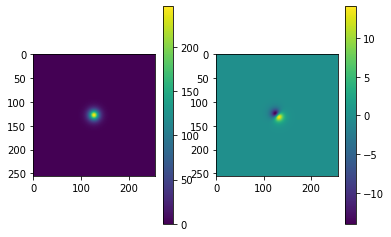

In [4]:
subplot(121)
imshow( ( obs_imag.array) ); colorbar();
subplot(122)
imshow( (obs_imag2.array - obs_imag.array) ); colorbar();

## We draw the PSF image in Kspace at the correct resolution

In [5]:
N = img_size
im_scale = pixel_scale
interp_factor=1
padding_factor=1
Nk = N*interp_factor*padding_factor
from galsim.bounds import _BoundsI

bounds = _BoundsI(-Nk//2, Nk//2-1, -Nk//2, Nk//2-1)

# K-image of galaxy
imgal = obs.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)

In [6]:
# Compute inverse fourier transform of K-image
rec = np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(imgal.array)))

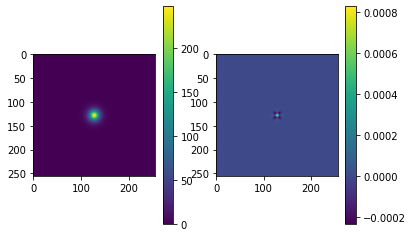

In [7]:
subplot(121)
imshow(rec.real); colorbar()
subplot(122)
imshow(rec.real-obs_imag2.array); colorbar()

In [16]:
## PSF K-image
impsf = psf.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)
## PSF deconvolution kernel (1/PSF*)
ipsf = galsim.Deconvolve(psf)

# K-image of PSF deconv kernel
imipsf = ipsf.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)

## Convert all to TF tensors

In [17]:
tfimpsf = tf.convert_to_tensor((impsf.array), dtype=tf.complex64)
tfimipsf = tf.convert_to_tensor((imipsf.array), dtype=tf.complex64)
tfimgal = tf.convert_to_tensor(imgal.array, dtype=tf.complex64)

In [18]:
tfimgal = tf.expand_dims(tfimgal ,0)
tfimpsf = tf.expand_dims(tfimpsf ,0)
tfimipsf = tf.expand_dims(tfimipsf ,0)
tfimpsf = tf.signal.fftshift(tfimpsf,axes=2)[:,:,:(img_size*interp_factor*padding_factor)//2+1]

## Deconvolve image

In [19]:
temp = tfimgal * tfimipsf
temp = tf.signal.fftshift(temp,axes=2)[:,:,:(img_size*interp_factor*padding_factor)//2+1]

## Reconvolve image

In [20]:
tst2 = gf.kconvolve(temp, tfimpsf)[...,0]
tst2 = tf.expand_dims(tf.signal.fftshift(tst2),-1)
tst2 = tf.image.resize_with_crop_or_pad(tst2, img_size, img_size)

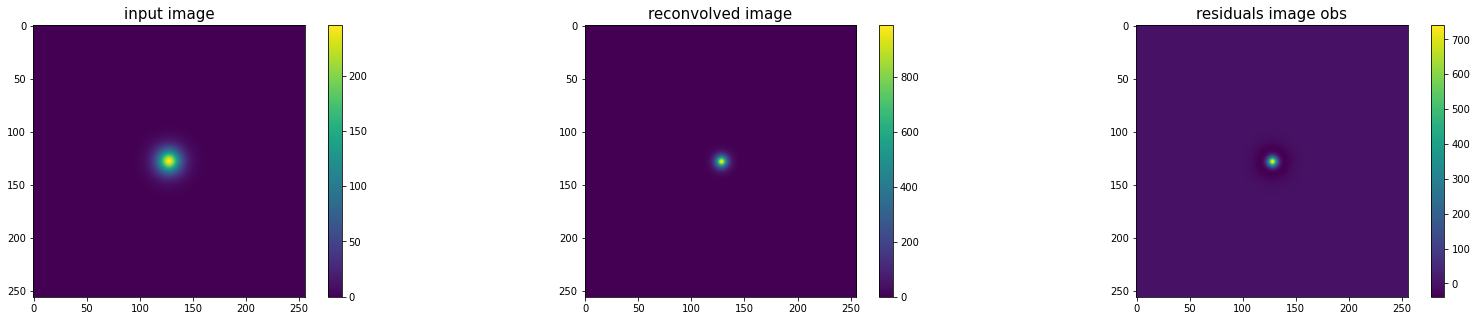

In [21]:
figure(figsize=[28,5])
subplot(131)
title('input image',fontsize=15)
imshow(obs_imag.array); colorbar();
subplot(132)
title('reconvolved image',fontsize=15)
imshow(tst2[0]);  colorbar();
subplot(133)
title('residuals image obs',fontsize=15)
imshow( (tst2[0,...,0] - obs_imag2.array) ); colorbar();